<a href="https://colab.research.google.com/github/fernandezsophia520/QLC_140G_SP26/blob/main/Coding_Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# coding exercise 3

- import a SSH (sea surface height) file and plot the SSH on a map

-Export figure and print for class


In [28]:
#import packages
#pandas, numpy, matplotlib, seaborn, cartopy.crs and cartopy.feature

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ssrs
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import scipy.interpolate as interp

In [2]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 82.9 MB/s eta 0:00:00


In [14]:
df_ssh = pd.read_csv('/ssh_practicedata.csv')

In [15]:
display(df_ssh.head(15))

,lat,lon,ssh
0,20,-80,0.12
1,20,-75,0.15
2,20,-70,0.18
3,20,-65,0.22
4,20,-60,0.25
5,20,-55,0.28
6,20,-50,0.30
7,25,-80,0.10
8,25,-75,0.14
9,25,-70,0.20


Figure exported as 'ssh_contour_map.png'


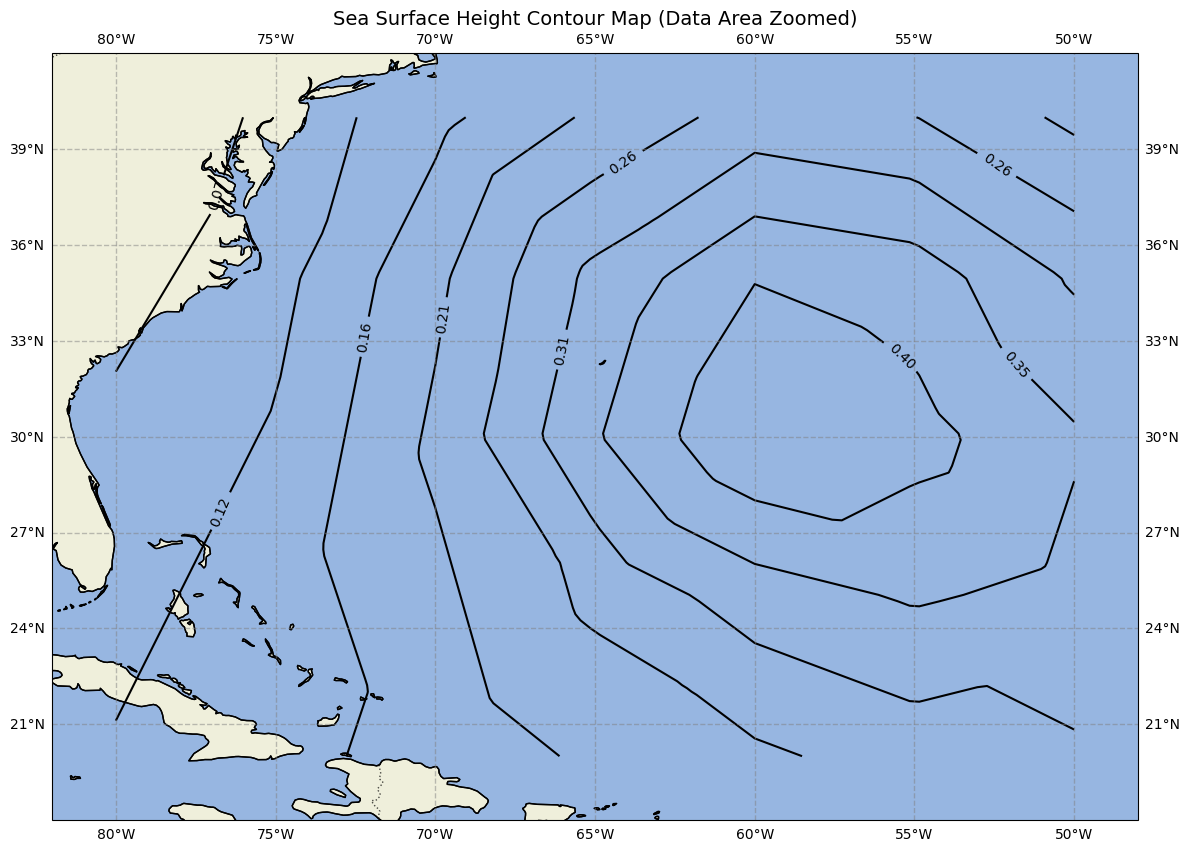

In [31]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add geographical features
ax.add_feature(cfeature.LAND, edgecolor='black', zorder=1)
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.7, zorder=2)

# Set the extent to focus on the area with data points
lon_min, lon_max = df_ssh['lon'].min(), df_ssh['lon'].max()
lat_min, lat_max = df_ssh['lat'].min(), df_ssh['lat'].max()
# Adding a small buffer around the data points for better visualization
ax.set_extent([lon_min - 2, lon_max + 2, lat_min - 2, lat_max + 2], crs=ccrs.PlateCarree())

# Prepare data for contour plot
# Create a grid with a reasonable resolution, e.g., 100x100 points
lon_grid = np.linspace(lon_min, lon_max, 100)
lat_grid = np.linspace(lat_min, lat_max, 100)
xi, yi = np.meshgrid(lon_grid, lat_grid)

# Interpolate the SSH data onto the new grid
points = df_ssh[['lon', 'lat']].values
values = df_ssh['ssh'].values
zi = interp.griddata(points, values, (xi, yi), method='linear')

# Define contour levels - you might want to adjust these based on your data range
levels = np.linspace(df_ssh['ssh'].min(), df_ssh['ssh'].max(), 10) # 10 contour lines

# Plot the SSH data as a contour plot with no color shaping (single color)
contour = ax.contour(xi, yi, zi, levels=levels, colors='black', transform=ccrs.PlateCarree(), linewidths=1.5)

# Label the contours
ax.clabel(contour, inline=True, fontsize=10, fmt='%1.2f')

# Set title and labels
ax.set_title('Sea Surface Height Contour Map (Data Area Zoomed)', fontsize=14)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Add gridlines
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.xlabels_top = False
gridlines.ylabels_right = False

plt.tight_layout()

# Export the image
plt.savefig('ssh_contour_map.png', dpi=300, bbox_inches='tight')
print("Figure exported as 'ssh_contour_map.png'")

plt.show()

In [ ]:
#export figure to download and print


In [ ]:
from IPython.display import Image
Image('ssh_contour_map.png')